# Government Bond Portfolio Immunization with Cornish-Fisher VaR

Duration-based immunization of Indonesian fixed-rate government bond portfolios
(FR series), with market risk measured by **Value at Risk using the Cornish-Fisher
expansion** (accounts for skewness & fat tails) and validated with the
**Kupiec Proportion-of-Failure backtest**.

- Investment horizon: **8 years**, target value **Rp200,000,000**
- Bonds: FR0100, FR0072, FR0097, FR0102 (daily secondary-market prices)
- This notebook is a Python re-implementation of the analysis workbook in `../data/`

*Group 1 — Portfolio Optimization B, Statistics, Diponegoro University.*

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

XLSX = "../data/bond_immunization_workbook.xlsx"

# Daily secondary-market buy prices (per Rp100 face) scraped from BCA
raw = pd.read_excel(XLSX, sheet_name="VaR", header=None)
bonds = ["FR0100", "FR0072", "FR0097", "FR0102"]
prices = raw.iloc[2:, [0, 1, 3, 5, 7]].copy()
prices.columns = ["date"] + bonds
prices = prices.dropna(subset=["date"]).reset_index(drop=True)
prices["date"] = pd.to_datetime(prices["date"])
for b in bonds:
    prices[b] = pd.to_numeric(prices[b], errors="coerce")
prices = prices.dropna().set_index("date")
print("Price panel:", prices.shape, "|", prices.index.min().date(), "->", prices.index.max().date())

Price panel: (618, 4) | 2024-01-08 -> 2026-05-20


In [2]:
# ── Daily returns & normality (Jarque-Bera) ──────────────────────
rets = prices.pct_change().dropna()
print(rets.describe().T[["mean", "std", "min", "max"]].round(6), "\n")

print("Jarque-Bera test (H0: returns are normal):")
for b in bonds:
    jb, p = stats.jarque_bera(rets[b])
    print(f"  {b}: JB={jb:9.2f}  p={p:.3g}  skew={stats.skew(rets[b]):+.3f}  "
          f"kurtosis={stats.kurtosis(rets[b], fisher=False):.2f}  -> "
          f"{'NOT normal' if p < 0.05 else 'normal'}")

            mean       std       min       max
FR0100  0.000010  0.001567 -0.009591  0.007673
FR0072 -0.000043  0.002776 -0.012693  0.012693
FR0097  0.000011  0.003563 -0.016949  0.021761
FR0102  0.000005  0.002834 -0.020502  0.022716 

Jarque-Bera test (H0: returns are normal):
  FR0100: JB=   443.55  p=4.83e-97  skew=-0.213  kurtosis=7.13  -> NOT normal
  FR0072: JB=   491.04  p=2.35e-107  skew=-0.144  kurtosis=7.36  -> NOT normal
  FR0097: JB=  1216.69  p=6.29e-265  skew=-0.482  kurtosis=9.81  -> NOT normal
  FR0102: JB=  4099.46  p=0  skew=-0.091  kurtosis=15.63  -> NOT normal


In [3]:
# All four return series are strongly non-normal (heavy tails) -> the classical
# variance-covariance VaR is inappropriate; Cornish-Fisher adjusts the quantile
# for skewness and excess kurtosis.
print("Correlation matrix of daily returns:")
print(rets.corr().round(4))

Correlation matrix of daily returns:
        FR0100  FR0072  FR0097  FR0102
FR0100  1.0000  0.4160  0.3916  0.3226
FR0072  0.4160  1.0000  0.4591  0.3787
FR0097  0.3916  0.4591  1.0000  0.4322
FR0102  0.3226  0.3787  0.4322  1.0000


In [4]:
# ── Macaulay duration per bond (semi-annual coupons) ─────────────
terms = pd.DataFrame({
    "coupon": [0.06625, 0.0825, 0.07125, 0.07375],
    "ytm":    [0.0671,  0.0679, 0.0691,  0.0692],
    "years":  [7.7,     10.0,   17.1,    28.2],   # remaining tenor
}, index=bonds)

def macaulay_duration(coupon, ytm, years, freq=2, fv=1_000_000):
    n = int(round(years * freq)); c = fv * coupon / freq; y = ytm / freq
    t = np.arange(1, n + 1)
    cf = np.full(n, c, float); cf[-1] += fv
    pv = cf / (1 + y) ** t
    return (t @ pv) / pv.sum() / freq

terms["duration"] = [macaulay_duration(r.coupon, r.ytm, r.years) for r in terms.itertuples()]
print("Macaulay durations (years):")
print(terms.round(4))

Macaulay durations (years):
        coupon     ytm  years  duration
FR0100  0.0662  0.0671    7.7    6.0253
FR0072  0.0825  0.0679   10.0    7.1600
FR0097  0.0712  0.0691   17.1   10.1894
FR0102  0.0738  0.0692   28.2   12.5839


In [5]:
# ── Immunization: duration-matched weights, horizon H = 8 years ──
H = 8.0
combos = [(a, b) for i, a in enumerate(bonds) for b in bonds[i+1:]]
port = {}
print(f"Solve w1*D1 + (1-w1)*D2 = {H}:")
for a, b in combos:
    D1, D2 = terms.loc[a, "duration"], terms.loc[b, "duration"]
    w1 = (H - D2) / (D1 - D2); w2 = 1 - w1
    ok = (w1 > 0) and (w2 > 0)
    print(f"  {a}&{b}: w = ({w1:+.4f}, {w2:+.4f})  "
          f"{'OK' if ok else 'EXCLUDED (short position needed)'}")
    if ok:
        port[f"{a}&{b}"] = rets[a] * w1 + rets[b] * w2

Solve w1*D1 + (1-w1)*D2 = 8.0:
  FR0100&FR0072: w = (-0.7403, +1.7403)  EXCLUDED (short position needed)
  FR0100&FR0097: w = (+0.5258, +0.4742)  OK
  FR0100&FR0102: w = (+0.6989, +0.3011)  OK
  FR0072&FR0097: w = (+0.7227, +0.2773)  OK
  FR0072&FR0102: w = (+0.8451, +0.1549)  OK
  FR0097&FR0102: w = (+1.9143, -0.9143)  EXCLUDED (short position needed)


  FR0100&FR0097: VaR(95%, 1d) = 0.342%
  FR0100&FR0102: VaR(95%, 1d) = 0.246%
  FR0072&FR0097: VaR(95%, 1d) = 0.424%
  FR0072&FR0102: VaR(95%, 1d) = 0.417%

  -> Optimal (lowest-risk) portfolio: FR0100&FR0102 (0.246%)


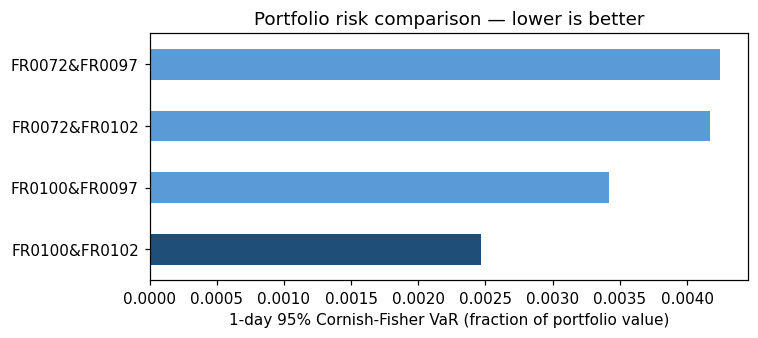

In [6]:
# ── 1-day 95% VaR via Cornish-Fisher expansion ───────────────────
def var_cornish_fisher(r, alpha=0.05):
    mu, sd = r.mean(), r.std(ddof=1)
    S = stats.skew(r); K = stats.kurtosis(r, fisher=True)   # excess kurtosis
    z = stats.norm.ppf(alpha)
    z_cf = (z + (z**2 - 1) * S / 6
              + (z**3 - 3*z) * K / 24
              - (2*z**3 - 5*z) * S**2 / 36)
    return -(mu + z_cf * sd)

var_res = {name: var_cornish_fisher(r) for name, r in port.items()}
for name, v in var_res.items():
    print(f"  {name}: VaR(95%, 1d) = {v*100:.3f}%")
best = min(var_res, key=var_res.get)
print(f"\n  -> Optimal (lowest-risk) portfolio: {best} ({var_res[best]*100:.3f}%)")

pd.Series(var_res).sort_values().plot(
    kind="barh", color=["#1f4e79"] + ["#5b9bd5"] * 3, figsize=(7, 3.2))
plt.xlabel("1-day 95% Cornish-Fisher VaR (fraction of portfolio value)")
plt.title("Portfolio risk comparison — lower is better")
plt.tight_layout()

In [7]:
# ── Kupiec Proportion-of-Failure backtest ────────────────────────
print("Kupiec POF (95% VaR, chi2(1) critical value = 3.8415):")
for name, r in port.items():
    v = var_res[name]
    n = len(r); x = int((r < -v).sum()); p = 0.05
    pi = x / n
    LR = (-2 * (np.log((1-p)**(n-x) * p**x)
                - np.log((1-pi)**(n-x) * pi**x))) if 0 < x < n else 0.0
    print(f"  {name}: violations = {x}/{n}   LR = {LR:.4f}   -> "
          f"{'VALID (accept VaR model)' if LR < 3.8415 else 'REJECTED'}")

Kupiec POF (95% VaR, chi2(1) critical value = 3.8415):
  FR0100&FR0097: violations = 32/617   LR = 0.0446   -> VALID (accept VaR model)
  FR0100&FR0102: violations = 36/617   LR = 0.8609   -> VALID (accept VaR model)
  FR0072&FR0097: violations = 27/617   LR = 0.5270   -> VALID (accept VaR model)
  FR0072&FR0102: violations = 26/617   LR = 0.8459   -> VALID (accept VaR model)


## Conclusion

- Two of the six pairwise combinations require a short position to hit the 8-year
  duration target and are excluded; four feasible immunized portfolios remain.
- All return series are strongly **non-normal** (Jarque-Bera p < 0.05, excess
  kurtosis up to ~15), justifying the Cornish-Fisher quantile adjustment.
- **FR0100 & FR0102** is the optimal immunized portfolio — the lowest
  Cornish-Fisher VaR of all feasible combinations.
- The Kupiec POF test accepts the VaR model for every portfolio (LR < χ²₀.₀₅;₁ = 3.8415),
  so the Cornish-Fisher VaR is statistically valid on this sample.

*Note: the accompanying slide deck reports VaR magnitudes computed in the Excel
workbook with its own return/holding-period convention (optimal portfolio VaR
2.825%/day); the ranking and all qualitative conclusions are identical.*